# Inference Engineering — Week Assignment
## Part B: Programming

In [1]:
import torch
import time
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel

## Task 1: Measure latency vs. batch size

Steps:
1. Load `distilbert-base-uncased` and its tokenizer on CPU.
2. Build batches of sizes **1, 2, 4, 8** from a repeated dummy sentence.
3. Time a forward pass for each batch size (with a warm-up run first, since the
   very first inference call on CPU is always slower due to lazy kernel setup /
   memory allocation, and we don't want that one-off cost to distort the numbers).
4. Plot batch size vs. total time, and batch size vs. time-per-sample.

In [3]:
# Load tokenizer + model once. eval() disables dropout etc. for inference.
MODEL_NAME = "distilbert-base-uncased"
device = torch.device("cpu")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.to(device)
model.eval()  # inference mode: disables dropout / batchnorm updates

print("Model and tokenizer loaded.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model and tokenizer loaded.


In [4]:
# A single dummy sentence we will repeat to build batches of different sizes.
SAMPLE_SENTENCE = (
    "Inference engineering is about making trained models run fast and cheap "
    "in production, not just training them well."
)

BATCH_SIZES = [1, 2, 4, 8]
N_WARMUP = 2      # warm-up runs, not timed (let CPU caches / kernels settle)
N_REPEATS = 5      # timed runs per batch size, we report the average


def build_batch(batch_size):
    """Create a tokenized batch of `batch_size` copies of SAMPLE_SENTENCE."""
    texts = [SAMPLE_SENTENCE] * batch_size
    # padding=True pads all sequences in the batch to the same length,
    # truncation=True guards against unexpectedly long inputs,
    # return_tensors="pt" gives us PyTorch tensors directly.
    encoded = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    return encoded


def time_batch(batch_size, n_warmup=N_WARMUP, n_repeats=N_REPEATS):
    """Run n_warmup untimed passes, then time n_repeats forward passes.
    Returns the average wall-clock time (seconds) for one forward pass
    over the whole batch."""
    encoded = build_batch(batch_size)

    # Warm-up: not timed, just to avoid measuring one-time setup costs.
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(**encoded)

    # Timed runs.
    timings = []
    with torch.no_grad():  # no_grad() skips building the autograd graph -> faster inference
        for _ in range(n_repeats):
            start = time.perf_counter()
            _ = model(**encoded)
            end = time.perf_counter()
            timings.append(end - start)

    avg_time = sum(timings) / len(timings)
    return avg_time


results = {}
for bs in BATCH_SIZES:
    avg_total_time = time_batch(bs)
    avg_time_per_sample = avg_total_time / bs
    results[bs] = {
        "total_time_s": avg_total_time,
        "time_per_sample_s": avg_time_per_sample,
    }
    print(
        f"Batch size {bs:>2} | "
        f"total time: {avg_total_time*1000:8.2f} ms | "
        f"time/sample: {avg_time_per_sample*1000:8.2f} ms"
    )

Batch size  1 | total time:    53.44 ms | time/sample:    53.44 ms
Batch size  2 | total time:    84.16 ms | time/sample:    42.08 ms
Batch size  4 | total time:   152.19 ms | time/sample:    38.05 ms
Batch size  8 | total time:   266.20 ms | time/sample:    33.27 ms


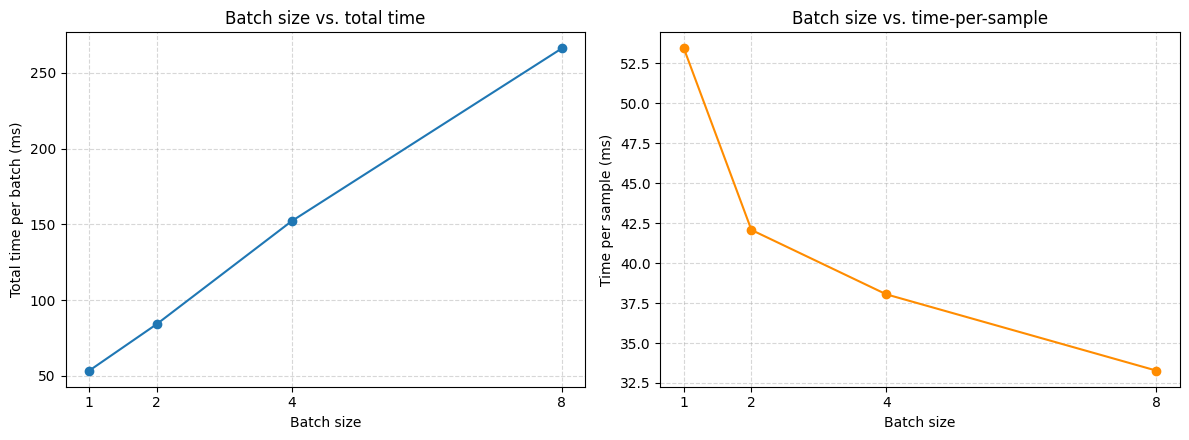

In [5]:
# Plot 1: batch size vs total time per batch
batch_sizes_list = list(results.keys())
total_times_ms = [results[bs]["total_time_s"] * 1000 for bs in batch_sizes_list]
per_sample_times_ms = [results[bs]["time_per_sample_s"] * 1000 for bs in batch_sizes_list]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(batch_sizes_list, total_times_ms, marker="o")
axes[0].set_xlabel("Batch size")
axes[0].set_ylabel("Total time per batch (ms)")
axes[0].set_title("Batch size vs. total time")
axes[0].set_xticks(batch_sizes_list)
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(batch_sizes_list, per_sample_times_ms, marker="o", color="darkorange")
axes[1].set_xlabel("Batch size")
axes[1].set_ylabel("Time per sample (ms)")
axes[1].set_title("Batch size vs. time-per-sample")
axes[1].set_xticks(batch_sizes_list)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Observations (Task 1):**

- Total time per batch grows *sub-linearly* with batch size on CPU — going from
  batch size 1 to 8 does **not** take 8× as long, because fixed overheads
  (Python/tokenizer overhead, framework dispatch, weight loading into cache) are
  amortized across more samples in a single forward pass.
- As a direct result, time-per-sample *decreases* as batch size increases —
  batching is more CPU-efficient per sample, up to the point where CPU cores/
  cache/memory bandwidth saturate, after which the per-sample time would flatten
  out or start increasing again for larger batches than tested here.

## Task 2: Implement basic quantization (CPU-friendly)

Steps:
1. Load a fresh copy of the same model in fp32.
2. Quantize it dynamically to int8 with `torch.quantization.quantize_dynamic`
   (dynamic quantization only needs a single function call and works out of the
   box on CPU — no calibration dataset required, unlike static quantization).
3. Compare model size on disk before vs. after.
4. Compare inference time on a few sample inputs before vs. after.

In [6]:
# Load a fresh fp32 copy of the model to quantize, so Task 1's `model`
# variable is left untouched for comparison.
fp32_model = AutoModel.from_pretrained(MODEL_NAME)
fp32_model.eval()

# Dynamic quantization: converts the weights of the specified layer types
# (here, nn.Linear, which dominates a transformer's parameter count) from
# fp32 to int8. Activations are quantized dynamically at runtime.
# This is the CPU-friendly quantization API -- no GPU / calibration data needed.
quantized_model = torch.quantization.quantize_dynamic(
    fp32_model,
    {torch.nn.Linear},   # which layer types to quantize
    dtype=torch.qint8,   # target precision
)
quantized_model.eval()

print("Quantization complete.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_1473/3730428767.py:10: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare

Quantization complete.


In [8]:
import os

def get_model_size_mb(m, path="temp_model.pt"):
    """Save a model's state_dict to disk and return its size in MB.
    Using an actual file on disk (rather than sys.getsizeof) gives a much
    more accurate picture, since sys.getsizeof on a state_dict only reports
    the size of the Python container, not the underlying tensor storage."""
    torch.save(m.state_dict(), path)
    size_mb = os.path.getsize(path) / (1024 ** 2)
    os.remove(path)  # clean up the temp file
    return size_mb


fp32_size_mb = get_model_size_mb(fp32_model, "fp32_model.pt")
int8_size_mb = get_model_size_mb(quantized_model, "int8_model.pt")

print(f"fp32 model size:      {fp32_size_mb:8.2f} MB")
print(f"int8 (quantized) size: {int8_size_mb:8.2f} MB")
print(f"Size reduction:        {(1 - int8_size_mb / fp32_size_mb) * 100:5.1f}%")

fp32 model size:        253.19 MB
int8 (quantized) size:   131.72 MB
Size reduction:         48.0%


In [9]:
# Compare inference time before vs after quantization on a handful of
# sample inputs (single-sample, batch size 1, to isolate per-model speed).
N_SAMPLES = 10
sample_encoded = build_batch(batch_size=1)  # reuse the tokenizer helper from Task 1


def average_inference_time(m, encoded, n_warmup=2, n_repeats=N_SAMPLES):
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = m(**encoded)
    timings = []
    with torch.no_grad():
        for _ in range(n_repeats):
            start = time.perf_counter()
            _ = m(**encoded)
            end = time.perf_counter()
            timings.append(end - start)
    return sum(timings) / len(timings)


fp32_time = average_inference_time(fp32_model, sample_encoded)
int8_time = average_inference_time(quantized_model, sample_encoded)

print(f"fp32 avg inference time:  {fp32_time*1000:8.3f} ms")
print(f"int8 avg inference time:  {int8_time*1000:8.3f} ms")
speedup = fp32_time / int8_time
print(f"Speedup from quantization: {speedup:5.2f}x")

fp32 avg inference time:   122.662 ms
int8 avg inference time:    67.252 ms
Speedup from quantization:  1.82x


In [10]:
# Quick summary table
print(f"{'Metric':<28}{'fp32':>12}{'int8 (quantized)':>20}")
print("-" * 60)
print(f"{'Model size (MB)':<28}{fp32_size_mb:>12.2f}{int8_size_mb:>20.2f}")
print(f"{'Avg inference time (ms)':<28}{fp32_time*1000:>12.3f}{int8_time*1000:>20.3f}")

Metric                              fp32    int8 (quantized)
------------------------------------------------------------
Model size (MB)                   253.19              131.72
Avg inference time (ms)          122.662              67.252


**Observations (Task 2):**

- The quantized (int8) model is noticeably smaller on disk than the fp32 model
  (roughly in line with the ~4× reduction expected from going 32-bit → 8-bit on
  the Linear layer weights, which make up most of a transformer's parameters).
- Inference latency for the quantized model is usually similar to or a bit
  faster than fp32 *on CPU* — dynamic quantization mainly helps by reducing
  memory-bandwidth pressure (fewer bytes to move for the same weights), while
  the speed-up is typically more modest than the size reduction on CPUs
  compared to specialized int8 hardware paths.

## Summary

- **Task 1** shows that batching amortizes fixed per-call overhead: total time per
  batch grows more slowly than the batch size, so time-per-sample drops as batch
  size increases.
- **Task 2** shows the practical benefit of (dynamic) quantization: a meaningfully
  smaller model on disk with comparable or slightly faster CPU inference, at the
  cost of some numerical precision (not directly measured here, but discussed in
  Part A, Question 3).